# PROACT in COVID-19 PBMC scATAC-seq data

This tutorial applies PROACT to condition-specific chromatin accessibility in COVID-19 PBMCs. Mild and severe disease states are compared within annotated cell types, followed by cooperative TF inference and motif-grammar analysis in selected cell states.

> **Reproducibility note:** The code-cell outputs shown in this notebook are preserved from the original analysis run. Local file paths reflect the original analysis environment and should be updated before rerunning the notebook.

## Load the preprocessed scATAC-seq dataset

In [2]:
library(Seurat)
load('examples/COVID-19/covid_19_hg38.rda')
covid_19

Loading required package: Signac



An object of class Seurat 
499218 features across 52817 samples within 4 assays 
Active assay: ATAC (195424 features, 195424 variable features)
 2 layers present: counts, data
 3 other assays present: peaks, prediction.score.id, raw
 3 dimensional reductions calculated: lsi, umap, harmony

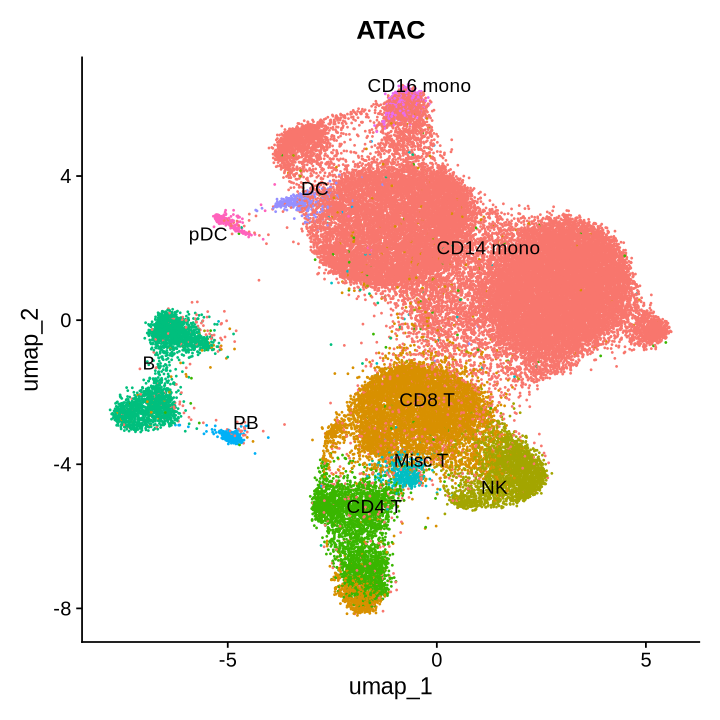

In [3]:
# UMAP
library(ggplot2)
options(repr.plot.width = 6, repr.plot.height = 6)
DimPlot(covid_19, 
        group.by = "celltype1", 
        label = T,
        repel = TRUE) + NoLegend() + ggtitle('ATAC')

In [4]:
# define new classification 
covid_19$Status <- ifelse(covid_19$MAX_SEVERITY_SCORE >= 4, "severe", "mild")
covid_19$cell.cond <- paste(covid_19$celltype1,covid_19$Status,sep = '.')
Idents(covid_19) <- "cell.cond"

## Identify condition-specific accessible peaks

In [5]:
# ==============================================================================
# Identify condition-specific differential accessible peaks
# ==============================================================================

DefaultAssay(covid_19) <- "ATAC"

# Compare severe vs mild within each cell type
idents <- unique(covid_19$celltype1)

vs_results <- do.call(rbind, lapply(idents, function(ident) {
    severe <- FindMarkers(
        object = covid_19, 
        ident.1 = paste0(ident, ".severe"),
        ident.2 = paste0(ident, ".mild"), 
        only.pos = TRUE,
        test.use = "wilcox", 
        logfc.threshold = 0.1
    )

    mild <- FindMarkers(
        object = covid_19, 
        ident.1 = paste0(ident, ".mild"),
        ident.2 = paste0(ident, ".severe"), 
        only.pos = TRUE,
        test.use = "wilcox", 
        logfc.threshold = 0.1
    )

    data.frame(
        ident = ident,
        severe_vs_mild = sum(severe$p_val_adj < 0.05),
        mild_vs_severe = sum(mild$p_val_adj < 0.05)
    )
}))

vs_results

ident,severe_vs_mild,mild_vs_severe
<fct>,<int>,<int>
CD8 T,20,5041
NK,3,36
CD16 mono,0,0
CD4 T,4,479
CD14 mono,1337,210
B,0,73
Misc T,0,0
pDC,0,6
DC,0,0


Based on the number of condition-specific differential accessible peaks, CD14 monocytes and CD8 T cells were retained for downstream PROACT analysis.

In [6]:
# CD14 monocytes: severe vs mild
cd14_peaks <- FindMarkers(
    object = covid_19,
    ident.1 = "CD14 mono.severe",
    ident.2 = "CD14 mono.mild",
    only.pos = TRUE,
    test.use = "wilcox",
    logfc.threshold = 0.1
)
cd14_peaks <- cd14_peaks[cd14_peaks$p_val_adj < 0.05, ]
cd14_peaks$Peak <- rownames(cd14_peaks)

# CD8 T cells: mild vs severe
cd8_peaks <- FindMarkers(
    object = covid_19,
    ident.1 = "CD8 T.mild",
    ident.2 = "CD8 T.severe",
    only.pos = TRUE,
    test.use = "wilcox",
    logfc.threshold = 0.1
)
cd8_peaks <- cd8_peaks[cd8_peaks$p_val_adj < 0.05, ]
cd8_peaks$Peak <- rownames(cd8_peaks)

da_peaks <- list(
    "CD14 mono.severe" = cd14_peaks$Peak,
    "CD8 T.mild" = cd8_peaks$Peak
)

sapply(da_peaks, length)

CD14 mono.severe       CD8 T.mild 
            1337             5041

## Prepare motif information

Two motif-derived inputs are prepared for PROACT. First, motif positions are stored in the scATAC-seq object for downstream spatial grammar analysis. Second, motifs are rescanned within the central 200 bp of each peak to generate a binary peak-by-motif matrix for cooperative TF inference.

In [7]:
# ==============================================================================
# Motif preparation for PROACT
# ==============================================================================

library(Signac)
library(motifmatchr)
library(TFBSTools)
library(JASPAR2024)
library(BSgenome.Hsapiens.UCSC.hg38)
library(GenomicRanges)
library(GenomeInfoDb)

DefaultAssay(covid_19) <- "ATAC"
genome <- BSgenome.Hsapiens.UCSC.hg38
p_cutoff <- 1e-4
region_length <- 200

# 1. Load JASPAR2024 human CORE motifs
pfm <- getMatrixSet(
    x = "data/JASPAR2024.sqlite",
    opts = list(collection = "CORE", tax_group = "vertebrates",
                species = "Homo sapiens", all_versions = FALSE)
)

# 2. Add motif matrix and motif positions to the scATAC-seq object
peak_gr <- granges(covid_19)

motif_matrix <- CreateMotifMatrix(
    features = peak_gr, pwm = pfm, genome = genome,
    use.counts = FALSE, p.cutoff = p_cutoff
)

keep <- as.character(seqnames(peak_gr)) %in% seqlevels(genome)

motif_positions <- motifmatchr::matchMotifs(
    pwms = pfm, subject = peak_gr[keep], out = "positions",
    genome = genome, p.cutoff = p_cutoff
)

seqinfo(motif_positions) <- seqinfo(genome)[seqlevels(motif_positions)]

motif_obj <- CreateMotifObject(
    data = motif_matrix,
    positions = motif_positions,
    pwm = pfm
)

covid_19[["ATAC"]]@motifs <- motif_obj

# Optional: save the object with motif positions for grammar analysis
saveRDS(covid_19, file = "examples/COVID-19/covid_19_preprocessed_with_motifs.rds")


# 3. Generate the central 200-bp peak x motif matrix
peak_gr <- granges(covid_19)
peak_gr$peakID <- rownames(covid_19[["ATAC"]])

chrom_sizes <- seqlengths(genome)
keep_chr <- intersect(c(paste0("chr", 1:22), "chrX", "chrY"), names(chrom_sizes))
chrom_sizes <- chrom_sizes[keep_chr]

peak_seqinfo <- Seqinfo(seqnames = names(chrom_sizes), seqlengths = chrom_sizes)
seqlevels(peak_gr) <- seqlevels(peak_seqinfo)
seqinfo(peak_gr) <- peak_seqinfo

peak_gr <- trim(resize(peak_gr, width = region_length, fix = "center"))

motif_matrix_200 <- CreateMotifMatrix(
    features = peak_gr, pwm = pfm, genome = genome,
    use.counts = FALSE, p.cutoff = p_cutoff
)

peak_motif <- as.data.frame(motif_matrix_200)
peak_motif[] <- lapply(peak_motif, function(x) if (is.logical(x)) as.integer(x) else x)
peak_motif <- data.frame(peakID = peak_gr$peakID, peak_motif, check.names = FALSE)

# Remove chrY only after motif scanning
peak_chr <- sub("-.*$", "", peak_motif$peakID)
peak_motif <- peak_motif[peak_chr %in% c(paste0("chr", 1:22), "chrX"),,drop = FALSE]


# 4. Retain motifs included in the PROACT annotation
motif_anno_file <- system.file("extdata", "metadata.tsv", package = "PROACT")
motif_anno <- read.table(motif_anno_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

keep_motifs <- intersect(motif_anno$motif_id, colnames(peak_motif))
peak_motif <- peak_motif[, c("peakID", keep_motifs), drop = FALSE]

write.table(
    peak_motif,
    file = "examples/COVID-19/covid_19_peak_motif.central200bp.p1e-4.tsv",
    row.names = FALSE, col.names = TRUE, sep = "\t", quote = FALSE
)



Loading required package: BiocFileCache

Loading required package: dbplyr

Loading required package: GenomeInfoDb

Loading required package: BiocGenerics

Loading required package: generics

Warning message:
“package ‘generics’ was built under R version 4.7.0”

Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



## Identify overrepresented motifs as target TFs

Motif enrichment was performed for ccondition-specific differential accessible peaks using FindMotifs. Significantly enriched motifs (FDR < 0.05) were ranked by adjusted P value and fold enrichment, and the top 100 motifs were mapped to TFs and used as target TFs for PROACT inference. You could also select TFs that you are interested in.  

In [8]:
# ==============================================================================
# Identification of target TFs
# ==============================================================================

# Calculate sequence features required by FindMotifs
covid_19 <- RegionStats(object = covid_19, assay = "ATAC", genome = BSgenome.Hsapiens.UCSC.hg38)


# Two cell types used for PROACT analysis
idents <- c("CD14 mono.severe","CD8 T.mild")

# Identify enriched motifs for each cell type
motif_enrichment <- lapply(idents, function(ident) {
    Idents(covid_19) <- "celltype1"
    open.peaks <- AccessiblePeaks(covid_19, idents = strsplit(ident,'\\.')[[1]][1])
    message(ident, " has ", length(open.peaks), " accessible peaks.")
    
    features <- da_peaks[[ident]]
    message(ident, " has ", length(features), " differential accessible peaks.")    
    
    meta.feature <- GetAssayData(covid_19, assay = "ATAC", layer = "meta.features")
    peaks.matched <- MatchRegionStats(
      meta.feature = meta.feature[open.peaks, ],
      query.feature = meta.feature[features, ],
      n = 50000
    )
    FindMotifs(object = covid_19, background = peaks.matched, features = features)
})
names(motif_enrichment) <- idents

# Remove redundant motifs using the default PROACT motif list
remove_motifs <- get("DEFAULT_REMOVE_MOTIFS", envir = asNamespace("PROACT"))
motif_anno <- motif_anno[!motif_anno$motif_id %in% remove_motifs, ]

# Select the top 100 significantly enriched motifs as target TFs
target_tfs <- lapply(motif_enrichment, function(df) {
    df <- df[df$motif %in% motif_anno$motif_id, ]
    df <- df[df$p.adjust < 0.05, ]
    df <- df[order(df$p.adjust, -df$fold.enrichment), ]
    df <- head(df, 100)

    tf <- motif_anno$tf_name[match(df$motif, motif_anno$motif_id)]
    unique(tf[!is.na(tf)])
})

# Number of target TFs retained for each cell type
sapply(target_tfs, length)

CD14 mono.severe has 195415 accessible peaks.

CD14 mono.severe has 1337 differential accessible peaks.

Matching GC.percent distribution

Testing motif enrichment in 1337 regions

CD8 T.mild has 160571 accessible peaks.

CD8 T.mild has 5041 differential accessible peaks.

Matching GC.percent distribution

Testing motif enrichment in 5041 regions



CD14 mono.severe       CD8 T.mild 
             100              100

## Filter TFs by scRNA-seq expression

Preprocessed covid-19 scRNA-seq data was downloaded from [here](https://www.covid19cellatlas.org/index.patient.html).

In [9]:
# ==============================================================================
# Filter TFs by scRNA-seq expression
# ==============================================================================

# Load the preprocessed scRNA-seq data
covid_rna <- readRDS('examples/COVID-19/blish_awilk_covid_seurat.rds')
#covid_rna

mdata <- covid_rna@meta.data
mdata$class <- 'healthy'
mdata[mdata$Severity.max.final=='1-3','class'] <- 'mild'
mdata[mdata$Severity.max.final=='4-5','class'] <- 'severe'
mdata[mdata$Severity.max.final=='6-7','class'] <- 'severe'
mdata[mdata$Severity.max.final=='8','class'] <- 'fatal'
mdata$cell.cond <- paste(mdata$cell.type.coarse,mdata$class,sep = '.')
covid_rna@meta.data$Class <- mdata$class
covid_rna@meta.data$cell.cond <- mdata$cell.cond
Idents(covid_rna) <- 'cell.cond'
DefaultAssay(covid_rna) <- 'RNA'
#table(Idents(covid_rna))

# Two cell types used for PROACT analysis
min_pct <- 0.05

# TFs included in the PROACT motif annotation
jaspar_tfs <- unique(motif_anno$tf_name)
jaspar_tfs <- intersect(jaspar_tfs, rownames(covid_rna))
#length(jaspar_tfs)

# Retain TFs expressed in at least 5% of cells in each cell type
expressed_tfs <- lapply(idents, function(ident) {
    cells <- WhichCells(covid_rna, idents = ident)
    expr <- GetAssayData(covid_rna, layer = "data")[jaspar_tfs, cells, drop = FALSE]
    pct_expr <- rowMeans(expr > 0)
    tfs <- sort(names(pct_expr[pct_expr >= min_pct]))
    message(ident, ": ", length(tfs), " TFs expressed in at least ", min_pct * 100, "% of cells.")
    tfs
})
names(expressed_tfs) <- idents

sapply(expressed_tfs, length)

CD14 mono.severe: 151 TFs expressed in at least 5% of cells.

CD8 T.mild: 111 TFs expressed in at least 5% of cells.



CD14 mono.severe       CD8 T.mild 
             151              111

## Run PROACT

PROACT was applied independently to two cell types. For each cell type, condition-specific differential accessible peaks were used to construct the peak-by-TF matrix, TFs with detectable scRNA-seq expression were retained, and the top enriched TF motifs were used as target TFs for cooperative TF inference.

In [10]:
# ==============================================================================
# Run PROACT
# ==============================================================================

library(PROACT)

# 1. Build the TF prior matrix
jaspar_tfs <- unique(motif_anno$tf_name)

prior_mat <- build_prior(
    jaspar_tfs,
    ppi_dir = "data/PPI_data/human"
)

# 2. Run PROACT for four PBMC cell types
proact_results <- lapply(idents, function(ident) {
    # Condition-specific differential accessible peaks
    dap <- da_peaks[[ident]]

    # Prepare peak x TF matrix
    peak_tf <- prepare_peak_tf_matrix(
        peak_motif_mat = peak_motif,
        da_peaks = dap,
        filter_expr = TRUE,
        expr_tfs = expressed_tfs[[ident]]
    )

    # Infer cooperative TF pairs
    result <- run_PROACT(
        peak_tf_matrix = peak_tf,
        prior_mat = prior_mat,
        target_tfs = target_tfs[[ident]],
        ncores = 4
    )

    list(peak_tf = peak_tf, result = result)
})

names(proact_results) <- idents

Loading PPI databases ...

Block1 pairs: 1870

Block2 pairs: 3626


Preparing Peak x TF matrix


After peak filtering: 1337 peaks

Removed 37 redundant motif columns

Using minimum motif count = 5

615 TFs retained

151 TFs retained after expression filtering

Final matrix: 1337 peaks x 151 TFs

151 TFs used for priority lasso

38 target TFs retained for modeling



  |                                                                      |   0%

KLF6: 144 TFs as predictors
KLF6:3:3:138




  |==                                                                    |   3%

CEBPD: 146 TFs as predictors
CEBPD:5:3:138




...

  |=================================================================     |  93%

ZNF148: 103 TFs as predictors
ZNF148:8:95




  |===================================================================   |  96%

KLF9: 105 TFs as predictors
KLF9:2:5:98




  |======================================================================| 100%



In [11]:
pair_results <- lapply(proact_results, `[[`, "result")

## Visualize a representative TF network

Anchor mode: 5 anchor TFs detected in network.



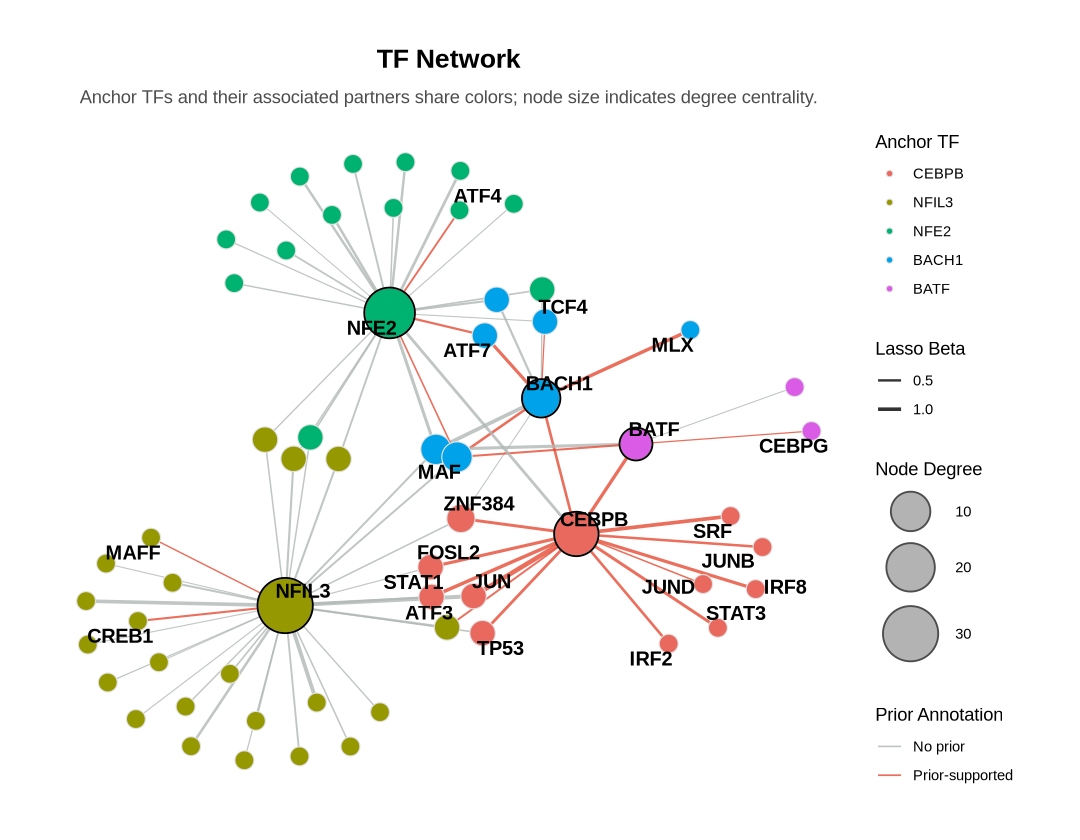

In [12]:
#TF-TF network
pair_candidates <- pair_results[['CD14 mono.severe']]
#plot_PROACT_network(pair_candidates = pair_candidates)
anchor_tfs <- c('CEBPB','NFIL3','NFE2','BACH1','BATF','JDP2')
pair_candidates_sub <- pair_candidates[pair_candidates$TF1 %in% anchor_tfs|pair_candidates$TF2 %in% anchor_tfs,]
options(repr.plot.width = 9, repr.plot.height = 7)
plot_PROACT_network(
    pair_candidates = pair_candidates_sub,
    anchor_tfs = anchor_tfs
)

## Analyze TF pair grammar

Dealing with 1337 features!



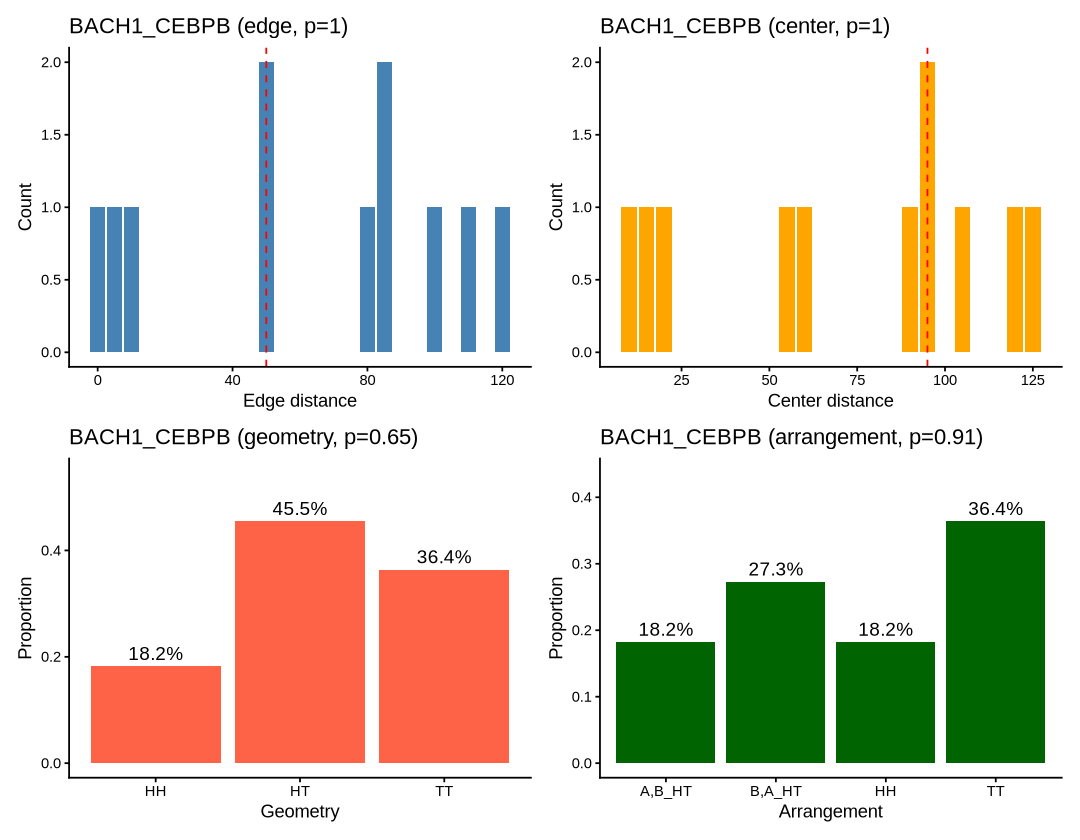

In [13]:
#TF grammar
features <- da_peaks[['CD14 mono.severe']]
pairs <- c('BACH1_CEBPB')
#1. detailed grammar features
pair_grammar <- find_grammar(object = covid_19, features = features,pairs = pairs,
                    strategy = 'best',assay = 'ATAC',region_length = 200,genome = BSgenome.Hsapiens.UCSC.hg38)
#pair_grammar$BACH1_CEBPB

#2. summary
res <- analyze_tf_grammar(result_list = pair_grammar)
#res

#3. plot
plot_tf_grammar(res, pair = pairs)

### Session Information

In [14]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.7 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/handongmei/miniconda3/envs/R4.4/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] PROACT_0.1.0                      BSgenome.Hsapiens.UCSC.hg38_1.4.5
 [3] BSgenome_1.72.0                   rtracklayer_1.64.0               
 [5] BiocIO_1.14.0                     Biostrings_2.72.1      